# Step 1

Run the following 3 "cells" by selecting them and pressing "Shift+Enter".

In [1]:
# Cell 1

import ipywidgets as widgets
from ipywidgets import IntSlider
from ipywidgets import interact, interactive, fixed, interact_manual, Layout
#import IPython.display as display
#from IPython.display import display
from IPython import display

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

from matplotlib import animation
#from IPython.display import HTML
from matplotlib import rc
rc('animation', html='html5') # equivalent to rcParams['animation.html'] = 'html5'

import numpy as np
from scipy.fft import fft, ifft

In [2]:
# Cell 2

#hbar = 1
#m = 1

def get_all_values(sliders):
    return [slider.value for slider in sliders]

def make_plot(hdisplay,ax,hist,ps,counts):
    for i in range(0,len(counts)):
        hist[i].set_height(counts[i])
    hdisplay.update(fig)

class plane_wave:
    def __init__(self, p, m):
        self.p = p # must be in [10^(-25) kg m/s]
        self.m = m # must be in [MeV]
        self.norm = 1.0/np.sqrt(2*np.pi*6.5821) # in [10^8]
        self.lam = 1.05457/self.p # in [nm]
        self.vel = self.p*4.4937/self.m # in [10^(-6) nm/s)]
        #self.norm = 1.0/np.sqrt(2*np.pi*hbar)
        #self.lam = hbar/self.p
        #self.vel = self.p/(2*self.m)
        
    
    
    def value(self,x,t):
        # t has to be in [10^(-6) s]
        arg = (x-self.vel*t)/self.lam
        return self.norm*np.cos(arg)

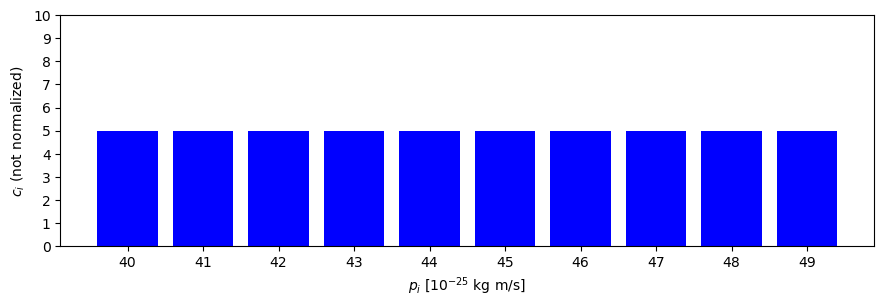

In [3]:
# Cell 3

# Define momentum values in units of [x10^(-25) kg m/s ]
ps = [40+x for x in range(0,10,1)]

# Define sliders
sliders = [0]*len(ps)
for i in range(0,len(ps)):
    sliders[i] = widgets.IntSlider(
        value=5,
        min=0,
        max=10,
        orientation='vertical',
        description='p'+str(i),
        readout=False
    )

# Arrange them side-by-side using HBox (Horizontal Box)
ui_sliders = widgets.HBox(
    sliders,
    layout=Layout(padding="0px 90px")
)

# Initial histogram
fig,ax = plt.subplots(figsize=(10.5, 3))
hdisplay = display.display(fig, display_id=True)
ax.set_ylim(0,10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_ylabel(r'$c_i$ (not normalized)')
ax.set_xlabel(r'$p_i$ [$10^{-25}$ kg m/s]')
counts = get_all_values(sliders)
hist = ax.bar(ps,counts,color="blue")
hdisplay.update(fig)

# Display the container
display.display(ui_sliders)

# Define update function for the 3D scatter plot
def update_plot(change):
    make_plot(hdisplay,ax,hist,ps,get_all_values(sliders))

# Attach the update function to the sliders' value change event
for slider in sliders:
    slider.observe(update_plot,'value')

plt.close()

# Step 2

Change the slide bars above that modify the amplitudes of the momentum space wave function $\phi(p)$, which in this case is a finite superposition (sum) of 10 momentum eigenstates. These are basically 10 plane, waves each with a different momentum (that defines its wavelentgh and velocity). You can set some of the coefficients to zero, leave only one plane wave, and make various combinations. Once you have made a choice, then execute the next cell to calculate the properly normalized amplitudes.

In [4]:
# Normalize coefficients
counts = get_all_values(sliders)
tmp_sum = 0
for i in range(0,len(counts)):
    tmp_sum = tmp_sum + counts[i]**2
coeffs = [ x/np.sqrt(tmp_sum) for x in counts ]

for i in range(0,len(coeffs)):
    print(f"p{i} = {ps[i]}, c{i} = {coeffs[i]:.3f}")
    
# Check normalization
dum = 0
for i in range(0,len(coeffs)):
    dum = dum + coeffs[i]**2
print()
print(f'Check: The sum of the squares of the amplitudes is: {dum:.3f}  (should be 1)')

p0 = 40, c0 = 0.316
p1 = 41, c1 = 0.316
p2 = 42, c2 = 0.316
p3 = 43, c3 = 0.316
p4 = 44, c4 = 0.316
p5 = 45, c5 = 0.316
p6 = 46, c6 = 0.316
p7 = 47, c7 = 0.316
p8 = 48, c8 = 0.316
p9 = 49, c9 = 0.316

Check: The sum of the squares of the amplitudes is: 1.000  (should be 1)


# Step 3

Set the mass of your particle and plot the corresponding wave function in position representation for $t=0$.

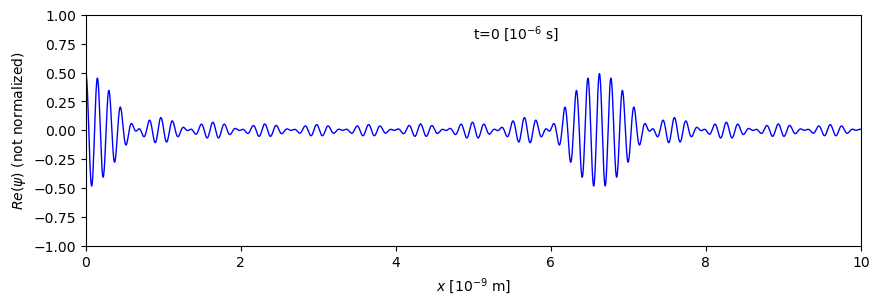

In [5]:
# Mass in [eV]
m = 0.511


# You don't need to change anything else in this cell below this line

# Create superposition
waves = [ plane_wave(p,m) for p in ps ]

def get_superposition(xs,t):
    ys = np.zeros(len(xs))
    for i in range(0,len(xs)):
        for k in range(0,len(waves)):
            ys[i] = ys[i] + coeffs[k]*waves[k].value(xs[i],t)
    return ys

# Plot superposition
xmin = 0 # in [nm]
xmax = 10 # in [nm]
N_xs = 3000 # number of points to use for plotting the wave



fig_anim,ax = plt.subplots(figsize=(10, 3))
#hdisplay = display.display(fig, display_id=True)
ax.set_xlim(xmin,xmax)
ax.set_ylim(-1,1)
ax.set_ylabel(r'$Re(\psi)$ (not normalized)')
ax.set_xlabel(r'$x$ [$10^{-9}$ m]')
time_step = ax.text(0.5,0.9,r't=0 [$10^{-6}$ s]',transform=ax.transAxes)


xs = np.linspace(xmin,xmax,N_xs)
ys = get_superposition(xs,0)
wave, = ax.plot(xs,ys, 'b', lw=1)

# Step 4

Plot the time evolved state for some time range. Note the 'carrier' and 'envelope' waves. Return to **Step 2**, change the amplitudes of the momentum wave function and repeat steps 3 and 4 to see how the wave patterns change. Try the following experiments:
- Create a single plane wave (fixed momentum, known with 100% probability).
- Create a state that is as well-localized in space as possible.

In the latter case, you may notice that you can get close but never really there. To actually achieve a well-localized wave pattern that "looks" like a particle, you will need a continuous superposition of momenta and not just the 10 values (eigenstates) that we are using here.

In [6]:
N_frames = 100 # number of frames in the animation

def drawframe(n):
    t = 0.00005*n # in [10^(-6) s]
    ys = get_superposition(xs,t)
    time_step.set_text(rf"t={1000*t:.2f} [$10^{{-9}}$ s]")
    wave.set_data(xs,ys)
    return (wave,wave,time_step)

anim = animation.FuncAnimation(fig_anim, drawframe, frames=N_frames, interval=100, blit=True)

#HTML(anim.to_html5_video())
anim

# Step 5 - Continuous superposition

Define the parameters of a normal distrubution (Gaussian).

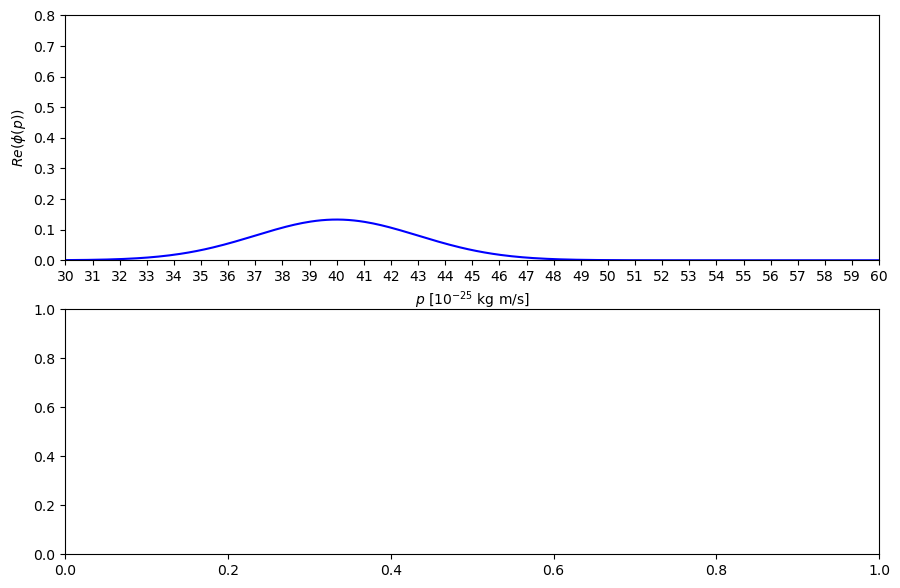

IntSlider(value=40, description='$p_0$', max=45, min=35)

FloatSlider(value=3.0, description='$\\beta$', max=10.0, min=0.1)

In [7]:
mu = 45
sig = 3

# You don't need to change anything else in this cell below this line

class my_normal:
    def __init__(self,mu,sigma):
        self._mu = mu
        self._sigma = sigma
        self._norm = 1.0/(np.sqrt(2*np.pi)*self._sigma)
    
    @property
    def mu(self):
        return self._mu

    @mu.setter
    def mu(self, value):
        self._mu = value
    
    @property
    def sigma(self):
        return self._sigma

    @mu.setter
    def sigma(self, value):
        self._sigma = value
        self._norm = 1.0/(np.sqrt(2*np.pi)*self._sigma)

    
    def value(self,x):
        expo = (x-self._mu)**2/(2*self._sigma**2)
        val = self._norm*np.exp(-expo)
        #if val < 0:
        #    return 0.0
        #else:
        #    return val
        return val

    def get_distr(self,ps_cont):
        re_phi_p = np.array([ self.value(p) for p in ps_cont ])
        return re_phi_p
        
def make_gauss_plot(hdisplay,ax,cont_hist,ps_cont,my_distr):
    re_phi_p = my_distr.get_distr(ps_cont)
    cont_hist[0].set_ydata(re_phi_p)
    #ax.set_ylim(bottom=1.2*max(re_phi_p))
    #print(max(re_phi_p))
    hdisplay.update(fig_gau)


p_min = 0
p_max = 100
N_samples = 1000
ps_cont = np.linspace(p_min,p_max,N_samples)

#print(re_phi_p.shape)



slider_mu = widgets.IntSlider(
    value=40,
    min=35,
    max=45,
    orientation='horizontal',
    description=r'$p_0$',
    readout=True
)
slider_sig = widgets.FloatSlider(
    value=3,
    min=0.1,
    max=10,
    step=0.1,
    orientation='horizontal',
    description=r'$\beta$',
    readout=True
)



# Initial histogram
fig_gau,axs = plt.subplots(2,1,figsize=(10.5, 7))
hdisplay_gau = display.display(fig_gau, display_id=True)
axs[0].set_xlim(30,60)
axs[0].set_ylim(0,0.8)
axs[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axs[0].set_ylabel(r'$Re(\phi(p))$')
axs[0].set_xlabel(r'$p$ [$10^{-25}$ kg m/s]')

my_distr = my_normal(slider_mu.value,slider_sig.value)
re_phi_p = my_distr.get_distr(ps_cont)
cont_hist = axs[0].plot(ps_cont,re_phi_p,color="blue")
#ax_gau.bar(ps,coeffs,color="grey")
hdisplay_gau.update(fig_gau)
display.display(slider_mu)
display.display(slider_sig)


# Define update function for the 3D scatter plot
def update_gauss_plot(change):
    my_distr = my_normal(slider_mu.value,slider_sig.value)
    make_gauss_plot(hdisplay_gau,axs[0],cont_hist,ps_cont,my_distr)

# Attach the update function to the sliders' value change event
slider_mu.observe(update_gauss_plot,'value')
slider_sig.observe(update_gauss_plot,'value')



plt.close()

In [8]:
hbar = 1

def my_fourier_transform(xs_cont,ps_cont,phi,t,m,hbar):
    
    N_samples = len(ps_cont)
    Dp = ps_cont[1]-ps_cont[0]
    norm = 1.0/np.sqrt(2*np.pi*hbar)
    
    N_out = len(xs_cont)
    real = np.zeros(N_out)
    img = np.zeros(N_out)
    
    for i in range(0,N_out):
        for j in range(0,N_samples):
            expo = (ps_cont[j]/hbar)*(xs_cont[i] - t*ps_cont[j]/(2*m))
            real[i] = real[i] + phi[j]*norm*np.cos(expo)*Dp
            img[i] = img[i] + phi[j]*norm*np.sin(expo)*Dp
    
    return real,img



    
my_distr = my_normal(slider_mu.value,slider_sig.value)
xs_cont = np.linspace(-xmax,xmax,N_xs)
re_phi_p = my_distr.get_distr(ps_cont)
    
t = 0
psi_real,psi_img = my_fourier_transform(xs_cont,ps_cont,re_phi_p,t,m,hbar)
    
#print(psi_real)
#print(psi_img)

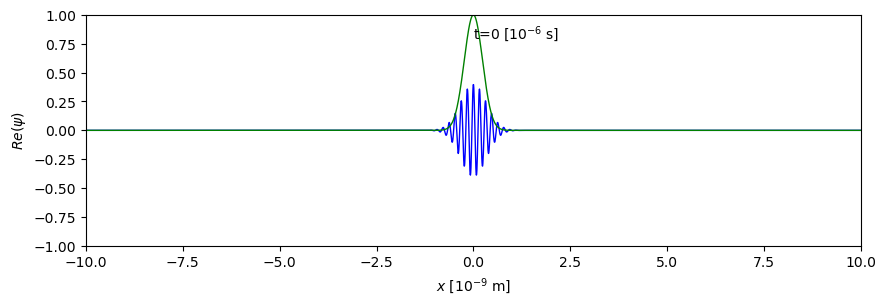

In [19]:
def gauss_envelope(x):
    p0 = slider_mu.value
    beta = slider_sig.value
    alpha = hbar/(2*beta)
    norm = np.power(1.0/(2*np.pi*alpha**2),0.25)
    
    values = np.zeros(len(x))
    for i in range(0,len(x)):
        expo = (x[i]-t*p0/m)**2/(4*alpha**2)
        values[i] = np.exp(-expo)
        
    return values

    


fig_trans,ax = plt.subplots(figsize=(10, 3))
ax.set_xlim(-xmax,xmax)
ax.set_ylim(-1,1)
ax.set_ylabel(r'$Re(\psi)$')
ax.set_xlabel(r'$x$ [$10^{-9}$ m]')
time_step = ax.text(0.5,0.9,r't=0 [$10^{-6}$ s]',transform=ax.transAxes)

ax.plot(xs_cont,psi_real, 'b', lw=1)
ax.plot(xs_cont,gauss_envelope(xs_cont), 'g', lw=1)

plt.show()
plt.close()